In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = datasets.cifar10
type(df)

module

In [3]:
(x_train, y_train), (x_test, y_test) = df.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [5]:
type(x_train),x_train.shape

(numpy.ndarray, (50000, 32, 32, 3))

In [6]:
x_train[0][0] # 1st row of 2D grid contains 32 RGB

array([[ 59,  62,  63],
       [ 43,  46,  45],
       [ 50,  48,  43],
       [ 68,  54,  42],
       [ 98,  73,  52],
       [119,  91,  63],
       [139, 107,  75],
       [145, 110,  80],
       [149, 117,  89],
       [149, 120,  93],
       [131, 103,  77],
       [125,  99,  76],
       [142, 115,  91],
       [144, 112,  86],
       [137, 105,  79],
       [129,  97,  71],
       [137, 106,  79],
       [134, 106,  76],
       [124,  97,  64],
       [139, 113,  78],
       [139, 112,  75],
       [133, 105,  69],
       [136, 105,  74],
       [139, 108,  77],
       [152, 120,  89],
       [163, 131, 100],
       [168, 136, 108],
       [159, 129, 102],
       [158, 130, 104],
       [158, 132, 108],
       [152, 125, 102],
       [148, 124, 103]], dtype=uint8)

In [8]:
x_train[0][0][1] # The 2nd pixel RGB

array([43, 46, 45], dtype=uint8)

In [9]:
unique_elements = np.unique(y_train)
unique_elements,np.unique(y_test)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8))

In [10]:
y_train[:5] # 2D array -> [ [a], [b], ..., [z..zz] ]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [13]:
y_train = y_train.reshape(-1,)  # Make 1D array -> [a, b, ..., z...z]
y_test = y_test.reshape(-1,)

In [14]:
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [15]:
classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

In [25]:
def plot_sample(x, y, index):
  print(y[index])
  plt.figure(figsize = (8, 1))
  plt.imshow(x[index])
  plt.xlabel(classes[y[index]])

8


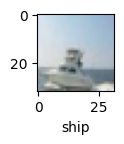

In [26]:
plot_sample(x_train, y_train,100)

In [29]:
x_train = x_train/255 # Dividing by 255 normalizes the values to the range 0 to 1
x_test = x_test/255   # normalized_pixel=pixel_value/255

In [30]:
ann = models.Sequential([
    layers.Flatten(input_shape = (32,32,3)),
    layers.Dense(2500, activation = 'relu'),
    layers.Dense(1000, activation = 'relu'),
    layers.Dense(10, activation = 'softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [31]:
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2500)           │     7,682,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1000)           │     2,501,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,193,510 (38.89 MB)

 Trainable params: 10,193,510 (38.89 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
ann.compile(loss = 'sparse_categorical_crossentropy',
            optimizer = 'rmsprop',
            metrics = ['accuracy'])

In [33]:
ann.fit(x_train, y_train, batch_size=64, epochs = 5)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 113s 143ms/step - accuracy: 0.0979 - loss: 2.3030
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 106s 135ms/step - accuracy: 0.0994 - loss: 2.3027
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 139s 132ms/step - accuracy: 0.0981 - loss: 2.3027
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 140s 129ms/step - accuracy: 0.0980 - loss: 2.3027
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 141s 128ms/step - accuracy: 0.0993 - loss: 2.3027


In [34]:
from sklearn.metrics import confusion_matrix, classification_report
y_pred = ann.predict(x_test)
y_pred = [np.argmax(i) for i in y_pred]
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1000
           1       0.00      0.00      0.00      1000
           2       0.10      1.00      0.18      1000
           3       0.00      0.00      0.00      1000
           4       0.00      0.00      0.00      1000
           5       0.00      0.00      0.00      1000
           6       0.00      0.00      0.00      1000
           7       0.00      0.00      0.00      1000
           8       0.00      0.00      0.00      1000
           9       0.00      0.00      0.00      1000

    accuracy                           0.10     10000
   macro avg       0.01      0.10      0.02     10000
weighted avg       0.01      0.10      0.02     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
cnn = models.Sequential([])

In [ ]:
cnn = models.Sequential([
    layers.Conv2D(filters = 32, kernel_size=(3,3), activation = 'relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters = 64, kernel_size=(3,3), activation = 'relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation = 'relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation = 'softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,322 (661.41 KB)

 Trainable params: 169,322 (661.41 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn.compile(loss = 'sparse_categorical_crossentropy',
            optimizer = 'rmsprop',
            metrics = ['Accuracy'])

In [ ]:
cnn.fit(x_train, y_train, batch_size=64, epochs = 5)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 60s 76ms/step - Accuracy: 0.2970 - loss: 1.9108
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 91s 87ms/step - Accuracy: 0.5351 - loss: 1.3058
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - Accuracy: 0.6171 - loss: 1.0855
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 72ms/step - Accuracy: 0.6604 - loss: 0.9733
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step - Accuracy: 0.6933 - loss: 0.8870


In [ ]:
cnn.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - Accuracy: 0.6178 - loss: 1.1014


[1.1153793334960938, 0.611299991607666]

In [ ]:
y_pred = cnn.predict(x_test)
y_pred = [np.argmax(i) for i in y_pred]
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


[np.int64(3), np.int64(8), np.int64(1), np.int64(0), np.int64(6)]

In [ ]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)